In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/insurance_data.csv")

df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [2]:
df.shape

df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           10000 non-null  str    
 1   Age                  10000 non-null  int64  
 2   Gender               10000 non-null  str    
 3   Province             10000 non-null  str    
 4   VehicleType          10000 non-null  str    
 5   AnnualIncome         10000 non-null  int64  
 6   RiskScore            10000 non-null  int64  
 7   AnnualPremium        10000 non-null  int64  
 8   Deductible           10000 non-null  int64  
 9   NCD                  10000 non-null  int64  
 10  PastClaims           10000 non-null  int64  
 11  Claimed              10000 non-null  bool   
 12  ClaimAmount          10000 non-null  float64
 13  TotalPremium         10000 non-null  int64  
 14  TotalClaims          10000 non-null  float64
 15  CoverType            10000 non-null  str    
 16

,Age,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,PastClaims,ClaimAmount,TotalPremium,TotalClaims,CustomValueEstimate,ZipCode
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,46.683500,79201.97390,58.140000,2488.127900,751.700000,20.935000,1.064200,1314.188500,2488.127900,1314.188500,35640.598700,23215.00050
std,16.717963,33039.93977,14.267486,735.674491,500.509401,14.549122,1.051945,3921.864903,735.674491,3921.864903,22353.988238,12848.33245
min,18.000000,17202.00000,15.000000,951.000000,250.000000,0.000000,0.000000,0.000000,951.000000,0.000000,5022.000000,10001.00000
25%,32.000000,56105.00000,48.000000,2028.000000,500.000000,10.000000,0.000000,0.000000,2028.000000,0.000000,21442.750000,10004.00000
50%,46.000000,72942.00000,57.000000,2307.000000,500.000000,20.000000,1.000000,0.000000,2307.000000,0.000000,28522.000000,20003.00000
75%,61.000000,95092.00000,67.000000,2676.000000,1000.000000,30.000000,2.000000,0.000000,2676.000000,0.000000,46721.000000,30004.00000
max,75.000000,376916.00000,95.000000,5105.000000,2000.000000,50.000000,5.000000,49623.000000,5105.000000,49623.000000,134914.000000,50005.00000


In [3]:
missing = df.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

In [4]:
df["LossRatio"] = df["TotalClaims"] / df["TotalPremium"]

overall_loss_ratio = (
    df["TotalClaims"].sum()
    /
    df["TotalPremium"].sum()
)

overall_loss_ratio

np.float64(0.5281836596904845)

In [5]:
province_loss = (
    df.groupby("Province")
      [["TotalPremium","TotalClaims"]]
      .sum()
)

province_loss["LossRatio"] = (
    province_loss["TotalClaims"]
    /
    province_loss["TotalPremium"]
)

In [6]:
gender_loss = (
    df.groupby("Gender")
      [["TotalPremium","TotalClaims"]]
      .sum()
)

gender_loss["LossRatio"] = (
    gender_loss["TotalClaims"]
    /
    gender_loss["TotalPremium"]
)

In [7]:
vehicle_loss = (
    df.groupby("VehicleType")
      [["TotalPremium","TotalClaims"]]
      .sum()
)

vehicle_loss["LossRatio"] = (
    vehicle_loss["TotalClaims"]
    /
    vehicle_loss["TotalPremium"]
)

<Axes: xlabel='TotalPremium', ylabel='Count'>

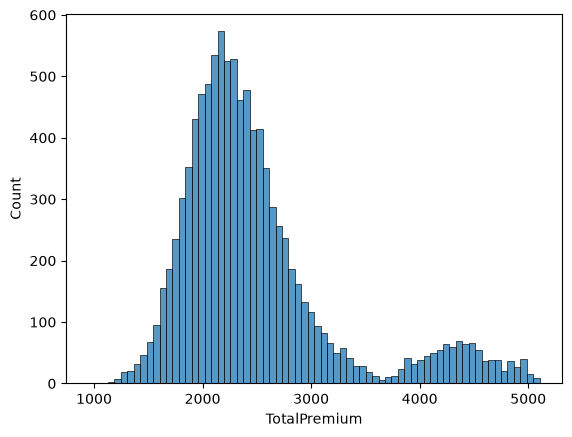

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df["TotalPremium"])

<Axes: xlabel='TotalClaims', ylabel='Count'>

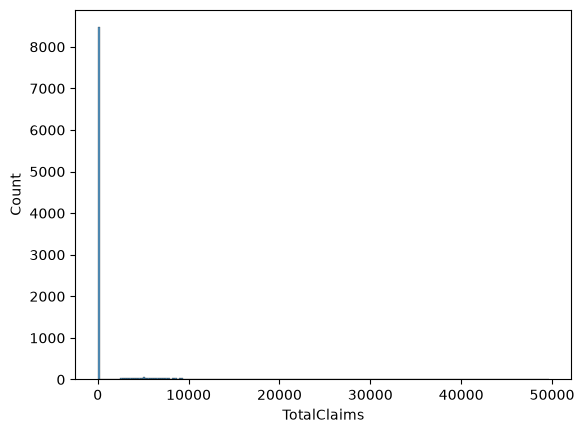

In [10]:
sns.histplot(df["TotalClaims"])

<Axes: ylabel='Province'>

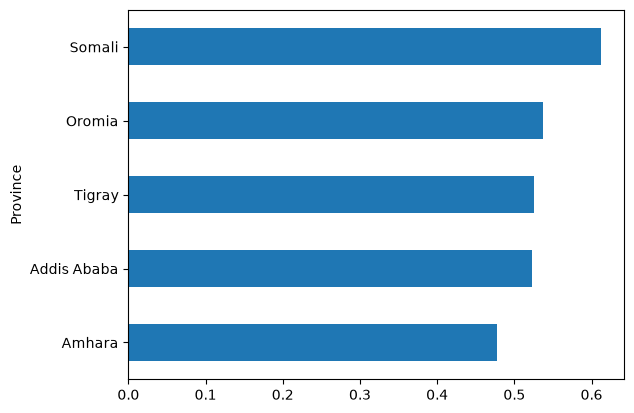

In [11]:
province_loss["LossRatio"].sort_values().plot(
    kind="barh"
)

<Axes: >

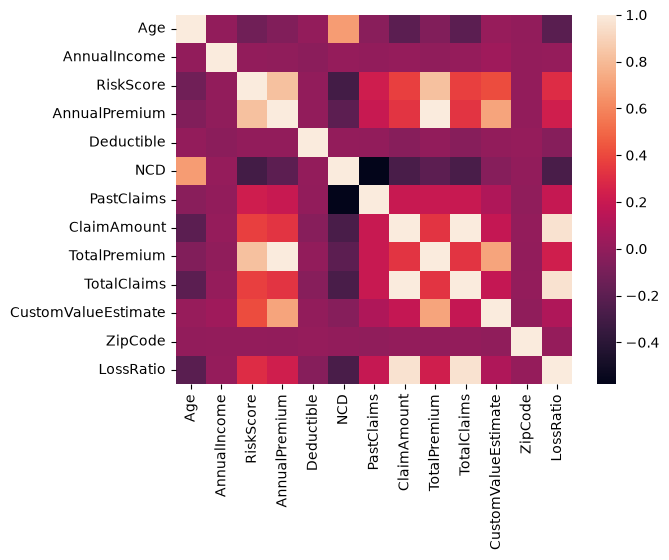

In [12]:
sns.heatmap(
    df.select_dtypes(include="number").corr()
)

<Axes: xlabel='TotalClaims'>

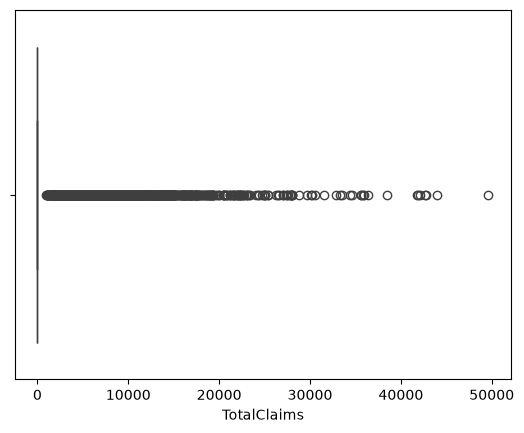

In [13]:
sns.boxplot(
    x=df["TotalClaims"]
)

In [14]:
import sys
sys.path.append("../src")

from eda_utils import (
    calculate_loss_ratio,
    missing_values,
    province_summary
)

In [15]:
loss_ratio = calculate_loss_ratio(df)

print(loss_ratio)

0.5281836596904845


In [16]:
missing_values(df)

,Missing_Count,Missing_Percentage
CustomerID,0,0.0
Age,0,0.0
Gender,0,0.0
Province,0,0.0
VehicleType,0,0.0
AnnualIncome,0,0.0
RiskScore,0,0.0
AnnualPremium,0,0.0
Deductible,0,0.0
NCD,0,0.0
